In [24]:
from cycler import cycler
import matplotlib.pyplot as plt
import numpy as np

FONT = 'Arial'
FONT_SIZE = 8
LINEWIDTH = 0.5
plt.rcParams.update({
    # DPI
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.transparent': True,

    # Font
    'font.family': 'sans-serif',
    'font.sans-serif': FONT,
    'font.size': FONT_SIZE,
    'axes.labelsize': FONT_SIZE,
    'axes.titlesize': FONT_SIZE,
    'xtick.labelsize': FONT_SIZE,
    'ytick.labelsize': FONT_SIZE,
    'legend.fontsize': FONT_SIZE,

    # Line width
    'axes.linewidth': LINEWIDTH,
    'grid.linewidth': LINEWIDTH,
    'lines.linewidth': LINEWIDTH,
    'patch.linewidth': LINEWIDTH,
    'xtick.major.width': LINEWIDTH,
    'xtick.minor.width': LINEWIDTH,
    'ytick.major.width': LINEWIDTH,
    'ytick.minor.width': LINEWIDTH,

    # === COLORMAPS ===
    # Default colormap for images (imshow, pcolormesh, TF, ecc.)
    'image.cmap': 'BuPu',

    # Color cycle for line plots (plot, butterfly, ecc.)
    'axes.prop_cycle': cycler(
        color=plt.cm.BuPu(np.linspace(0.2, 0.9, 10))
    ),

    # Grid (opzionale ma consigliato)
    'axes.grid': False,
    'grid.alpha': 0.15,
    'grid.linestyle': '--',
})

In [2]:
import eelbrain as eel
import pickle

trf_list = []
subjects = ['04', '05', '06', '07', '09', '10', '11', '14', '15','16', '18', '19']

for subj in subjects:
    with open(f"C:\\Users\\schia\\OneDrive - Alma Mater Studiorum Università di Bologna\\Desktop\\IMT\\TESI\\linguistic_pipeline_EEG\\eeg_pipeline\\TRF\\prove\\TRF_freq_6partitions\\TRF_freq_{subj}.pkl", "rb") as f:
        trf_h = pickle.load(f)
    trf_list.append(trf_h)

print(trf_list)

[<BoostingResult EEG ~ Word Frequency, -0.2 - 0.6, basis=0.08, partitions=6, test=True, selective_stopping=4, partition_results=True>, <BoostingResult EEG ~ Word Frequency, -0.2 - 0.6, basis=0.08, partitions=6, test=True, selective_stopping=4, partition_results=True>, <BoostingResult EEG ~ Word Frequency, -0.2 - 0.6, basis=0.08, partitions=6, test=True, selective_stopping=4, partition_results=True>, <BoostingResult EEG ~ Word Frequency, -0.2 - 0.6, basis=0.08, partitions=6, test=True, selective_stopping=4, partition_results=True>, <BoostingResult EEG ~ Word Frequency, -0.2 - 0.6, basis=0.08, partitions=6, test=True, selective_stopping=4, partition_results=True>, <BoostingResult EEG ~ Word Frequency, -0.2 - 0.6, basis=0.08, partitions=6, test=True, selective_stopping=4, partition_results=True>, <BoostingResult EEG ~ Word Frequency, -0.2 - 0.6, basis=0.08, partitions=6, test=True, selective_stopping=4, partition_results=True>, <BoostingResult EEG ~ Word Frequency, -0.2 - 0.6, basis=0.08,

In [3]:
TRFs = []
for i in trf_list:
    TRFs.append(i.r)
print(TRFs)
import numpy as np

TRF_mean_all = sum(TRFs) / len(TRFs)  # NDVar sensor × lag
print(TRF_mean_all)

[<NDVar 'Correlation': 65 sensor>, <NDVar 'Correlation': 65 sensor>, <NDVar 'Correlation': 65 sensor>, <NDVar 'Correlation': 65 sensor>, <NDVar 'Correlation': 65 sensor>, <NDVar 'Correlation': 65 sensor>, <NDVar 'Correlation': 65 sensor>, <NDVar 'Correlation': 65 sensor>, <NDVar 'Correlation': 65 sensor>, <NDVar 'Correlation': 65 sensor>, <NDVar 'Correlation': 65 sensor>, <NDVar 'Correlation': 65 sensor>]
<NDVar '0': 65 sensor>


0.01860016361311853


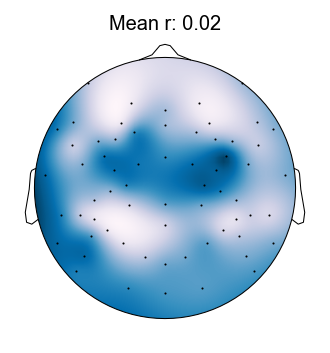

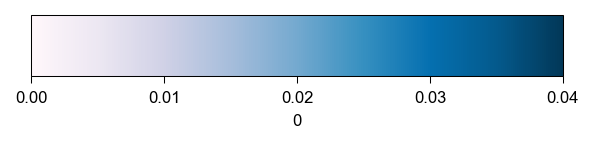

In [26]:
mean_r = TRF_mean_all.mean()
print(mean_r)
title = f"Mean r: {mean_r:.2f}"
p = eel.plot.Topomap(TRF_mean_all, clip='circle',title=title, cmap='PuBu')
pcb = p.plot_colorbar()

In [23]:
h_list = [trf.h for trf in trf_list]
h = eel.combine(h_list, name='h_word_frequency')
print(h)

<NDVar 'h_word_frequency': 12 case, 65 sensor, 87 time>


['E1', 'E2', 'E3', 'E4', 'E5', 'E6', 'E7', 'E8', 'E9', 'E10', 'E11', 'E12', 'E13', 'E14', 'E15', 'E16', 'E17', 'E18', 'E19', 'E20', 'E21', 'E22', 'E23', 'E24', 'E25', 'E26', 'E27', 'E28', 'E29', 'E30', 'E31', 'E32', 'E33', 'E34', 'E35', 'E36', 'E37', 'E38', 'E39', 'E40', 'E41', 'E42', 'E43', 'E44', 'E45', 'E46', 'E47', 'E48', 'E49', 'E50', 'E51', 'E52', 'E53', 'E54', 'E55', 'E56', 'E57', 'E58', 'E59', 'E60', 'E61', 'E62', 'E63', 'E64', 'Cz']


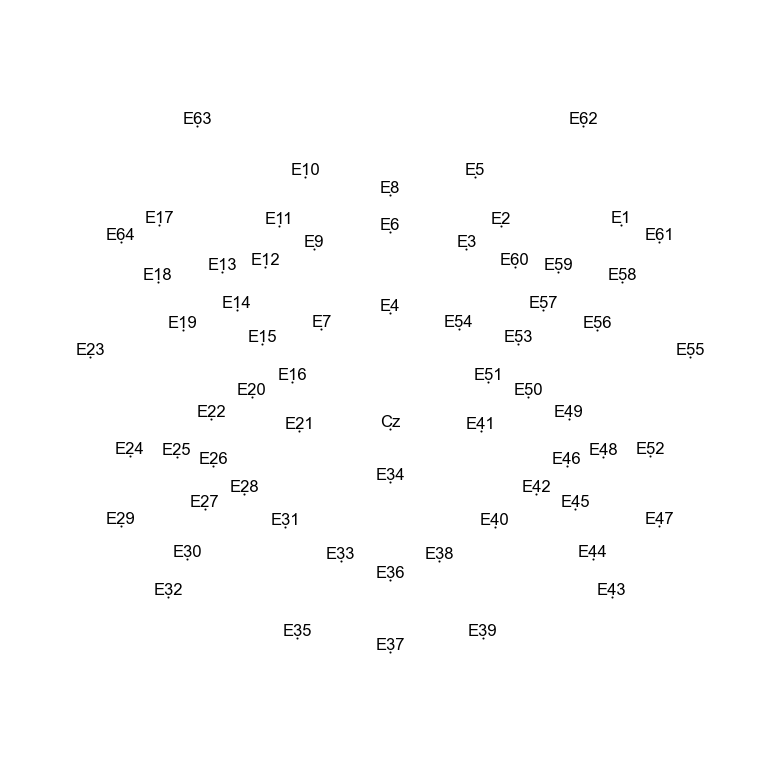

In [20]:
sensor= eel.Sensor.from_montage('GSN-HydroCel-65_1.0')
print(sensor.names)  # tutti i 65 canali
p =eel.plot.SensorMap(sensor)

**Clusters**
- parietale: 38 36 33 34 31 40 28 42 21 41 65
- centrale: 65 16 7 4 54 51

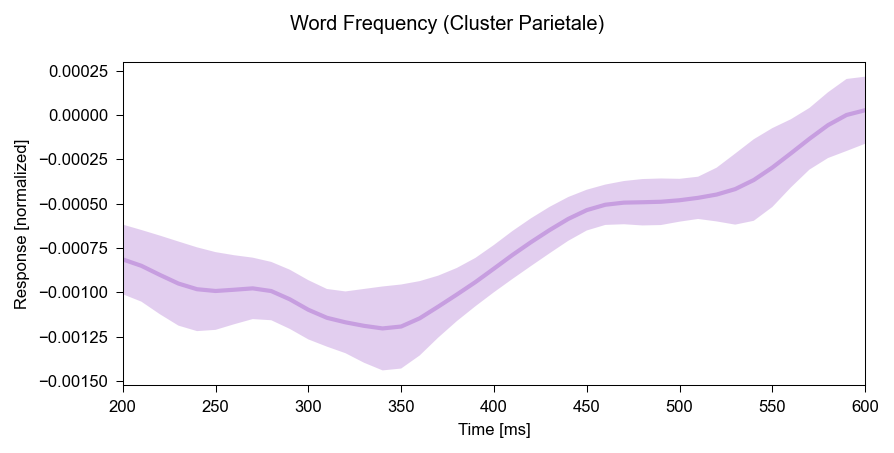

In [76]:
roi = ['E38', 'E36', 'E33', 'E34', 'E31', 'E40', 'E28', 'E42', 'E21', 'E41', 'E28', 'E21', 'E42', 'Cz']

h_roi = h.sub(sensor=roi).smooth('time', 0.05)
h_roi_mean = h_roi.mean('sensor')

p = eel.plot.UTSStat(
    h_roi_mean,
    xlim=(0.2, 0.6),
    title='Word Frequency (Cluster Parietale)', axh=3, error_alpha = 0.5, colors=(0.78, 0.62, 0.88)
    
)
ax = p.axes[0]
ax.lines[0].set_linewidth(2)

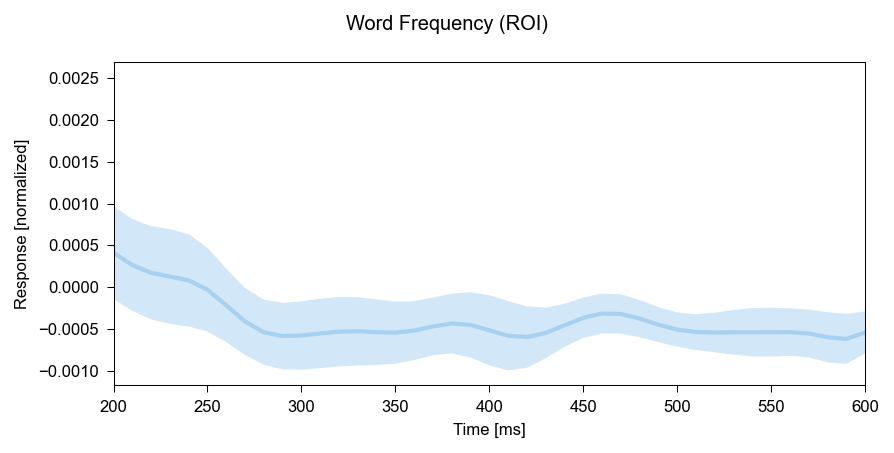

In [ ]:

roi = ['Cz', 'E16', 'E7', 'E4', 'E54', 'E51']

h_roi = h.sub(sensor=roi).smooth('time', 0.05)
h_roi_mean = h_roi.mean('sensor')

p = eel.plot.UTSStat(
    h_roi_mean,
    xlim=(0.2, 0.6),
    title='Word Frequency (Cluster Centrale)', axh=3, colors=(0.65, 0.82, 0.95), error_alpha = 0.5
    
)

ax = p.axes[0]
ax.lines[0].set_linewidth(2)